# 🏥 Healthcare Patient Analytics & Risk Analysis System

## Phase 1 — Day 1: Data Understanding

### Objective

The objective of this day is to understand the healthcare
patient dataset before performing any data cleaning or analysis.

We will examine:

- Dataset size
- Columns
- Data types
- Missing values
- Duplicate rows
- Numerical statistics
- Categorical variables
- Patient demographics
- Initial distributions


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
df = pd.read_csv("/content/healthcare_patients.csv")

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,patient_id,age,gender,blood_pressure,heart_rate,bmi,smoking_status,diabetes,hypertension,disease,admission_type,length_of_stay,medication_count,treatment_cost,readmission,risk_score
0,103475,84,Female,144.0,81.0,21.2,Current,No,No,Healthy/Preventive,Urgent,5,2.0,19148.0,No,45.9
1,105328,42,Male,130.0,104.0,34.2,Never,No,No,Hypertension,Emergency,7,3.0,28092.0,No,42.5
2,102009,56,Female,127.0,71.0,28.8,Current,Yes,Yes,Other,Urgent,7,8.0,20706.0,No,56.4
3,104186,54,Female,148.0,70.0,31.8,Never,No,Yes,Diabetes,Emergency,5,6.0,25249.0,No,62.9
4,108876,57,Male,130.0,96.0,26.7,Never,No,No,Healthy/Preventive,Elective,3,4.0,14612.0,No,28.2


In [7]:
# First dataset inspection
df.shape
df.columns
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   patient_id        10020 non-null  int64  
 1   age               10020 non-null  int64  
 2   gender            10020 non-null  object 
 3   blood_pressure    9870 non-null   float64
 4   heart_rate        9900 non-null   float64
 5   bmi               9840 non-null   float64
 6   smoking_status    9920 non-null   object 
 7   diabetes          10020 non-null  object 
 8   hypertension      10020 non-null  object 
 9   disease           10020 non-null  object 
 10  admission_type    10020 non-null  object 
 11  length_of_stay    10020 non-null  int64  
 12  medication_count  9900 non-null   float64
 13  treatment_cost    9940 non-null   float64
 14  readmission       10020 non-null  object 
 15  risk_score        10020 non-null  float64
dtypes: float64(6), int64(3), object(7)
memor

,0
patient_id,int64
age,int64
gender,object
blood_pressure,float64
heart_rate,float64
bmi,float64
smoking_status,object
diabetes,object
hypertension,object
disease,object


In [8]:
# Missing values
df.isnull().sum()
df.isnull().sum().sum()

np.int64(750)

In [9]:
# Duplicate rows
df.duplicated().sum()

np.int64(20)

In [10]:
# Numerical statistics
df.describe()

print(df['gender'].value_counts(),
df['disease'].value_counts(),
df['admission_type'].value_counts(),
df['smoking_status'].value_counts(),
df["readmission"].value_counts())

gender
Male      4937
Female    4896
Other      187
Name: count, dtype: int64 disease
Hypertension           1886
Healthy/Preventive     1804
Diabetes               1610
Heart Disease          1148
Other                  1132
Respiratory Disease    1125
Kidney Disease          675
Cancer                  640
Name: count, dtype: int64 admission_type
Elective     4375
Emergency    3171
Urgent       2474
Name: count, dtype: int64 smoking_status
Never      5716
Former     2466
Current    1738
Name: count, dtype: int64 readmission
No     7952
Yes    2068
Name: count, dtype: int64


In [11]:
# Categorical variables
df.describe(include=['object'])

,gender,smoking_status,diabetes,hypertension,disease,admission_type,readmission
count,10020,9920,10020,10020,10020,10020,10020
unique,3,3,2,2,8,3,2
top,Male,Never,No,No,Hypertension,Elective,No
freq,4937,5716,8055,7156,1886,4375,7952


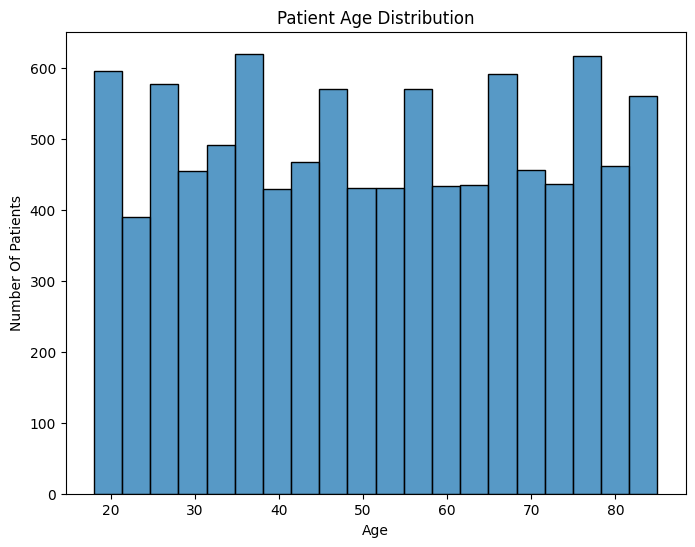

In [12]:
# First visualization
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', bins=20)
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number Of Patients')
plt.show()

In [13]:
# Data quality summary
data_summary = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique()
})

data_summary

,data_type,missing_values,unique_values
patient_id,int64,0,10000
age,int64,0,68
gender,object,0,3
blood_pressure,float64,150,99
heart_rate,float64,120,79
bmi,float64,180,268
smoking_status,object,100,3
diabetes,object,0,2
hypertension,object,0,2
disease,object,0,8


In [14]:
df.shape
df.nunique()

,0
patient_id,10000
age,68
gender,3
blood_pressure,99
heart_rate,79
bmi,268
smoking_status,3
diabetes,2
hypertension,2
disease,8


In [15]:
# Missing value percentage
missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_percentage
missing_percentage[missing_percentage > 0]



,0
blood_pressure,1.497006
heart_rate,1.197605
bmi,1.796407
smoking_status,0.998004
medication_count,1.197605
treatment_cost,0.798403


In [16]:
df.describe()

,patient_id,age,blood_pressure,heart_rate,bmi,length_of_stay,medication_count,treatment_cost,risk_score
count,10020.000000,10020.000000,9870.000000,9900.000000,9840.000000,10020.000000,9900.000000,9940.000000,10020.000000
mean,104996.770160,51.518164,128.272543,77.924747,26.305467,6.499601,2.817778,29976.888632,46.426647
std,2887.254587,19.607287,17.645118,11.869977,4.974323,3.191824,1.856322,15480.652599,18.262592
min,100001.000000,18.000000,90.000000,45.000000,15.000000,1.000000,0.000000,800.000000,1.000000
25%,102496.750000,34.000000,116.000000,70.000000,22.900000,4.000000,1.000000,18679.500000,33.400000
50%,104993.500000,51.000000,128.000000,78.000000,26.300000,6.000000,3.000000,27953.000000,45.200000
75%,107497.250000,69.000000,140.000000,86.000000,29.600000,8.000000,4.000000,38959.750000,58.400000
max,110000.000000,85.000000,190.000000,127.000000,45.000000,22.000000,12.000000,101926.000000,100.000000


## 📋 Day 1 Observations

### Dataset Size

- Number of rows: 10,020
- Number of columns: 16
- The dataset contains 20 duplicate rows.

### Data Types

- Numerical variables: 9
- Categorical variables: 7

### Data Quality

- Total missing values: 750
- Missing values are present in blood_pressure, heart_rate, bmi,
  smoking_status, medication_count, and treatment_cost.
- Duplicate rows: 20

### Patient Demographics

- Most common gender: Male
- Male and Female records are relatively close in number.
- Patient ages range from 18 to 85 years.
- Mean patient age: approximately 51.52 years.

### Disease Information

- Most common disease category: Hypertension
- Hypertension is followed by Healthy/Preventive and Diabetes.

### Admission Information

- Most common admission type: Elective
- Emergency admissions are the second most common category.

### Smoking Status

- Most common smoking status: Never
- Former smokers are more common than Current smokers.

### Readmission

- Most records have a readmission status of No.
- 2,068 records have a readmission status of Yes.

### Numerical Variables

- Mean BMI: approximately 26.31
- Mean heart rate: approximately 77.92
- Mean length of stay: approximately 6.50 days
- Mean medication count: approximately 2.82
- Mean treatment cost: approximately ₹29,976.89
- Mean risk score: approximately 46.43

### Initial Observation

The dataset contains a mixture of demographic, clinical,
admission, treatment, cost, and risk-related variables. It also
contains intentionally introduced missing values and duplicate
records, which will be handled during the data cleaning phase.

# 📊 Day 2 — Deeper Data Understanding

## Objective

The objective of Day 2 is to understand the distributions
and basic relationships between important healthcare variables.

We will analyze:

- Numerical variable distributions
- Categorical variable percentages
- Patient age groups
- Disease distribution
- Admission types
- Readmission rate
- Basic relationships between variables

## 1. Numerical Variable Distributions

We will examine the distributions of:

- Age
- Blood Pressure
- Heart Rate
- BMI
- Length of Stay
- Medication Count
- Treatment Cost
- Risk Score


In [17]:
numerical_columns = [
    "age",
    "blood_pressure",
    "heart_rate",
    "bmi",
    "length_of_stay",
    "medication_count",
    "treatment_cost",
    "risk_score"
]

df[numerical_columns].describe()

,age,blood_pressure,heart_rate,bmi,length_of_stay,medication_count,treatment_cost,risk_score
count,10020.000000,9870.000000,9900.000000,9840.000000,10020.000000,9900.000000,9940.000000,10020.000000
mean,51.518164,128.272543,77.924747,26.305467,6.499601,2.817778,29976.888632,46.426647
std,19.607287,17.645118,11.869977,4.974323,3.191824,1.856322,15480.652599,18.262592
min,18.000000,90.000000,45.000000,15.000000,1.000000,0.000000,800.000000,1.000000
25%,34.000000,116.000000,70.000000,22.900000,4.000000,1.000000,18679.500000,33.400000
50%,51.000000,128.000000,78.000000,26.300000,6.000000,3.000000,27953.000000,45.200000
75%,69.000000,140.000000,86.000000,29.600000,8.000000,4.000000,38959.750000,58.400000
max,85.000000,190.000000,127.000000,45.000000,22.000000,12.000000,101926.000000,100.000000


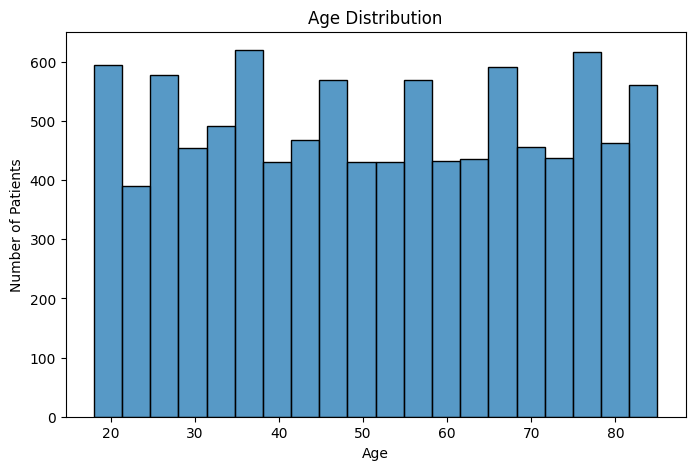

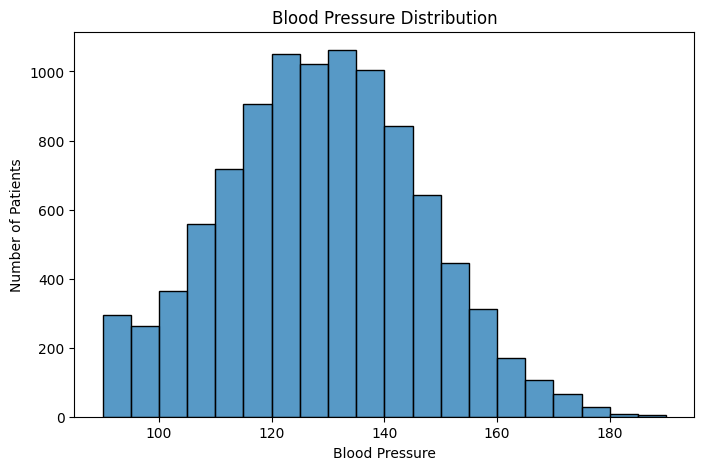

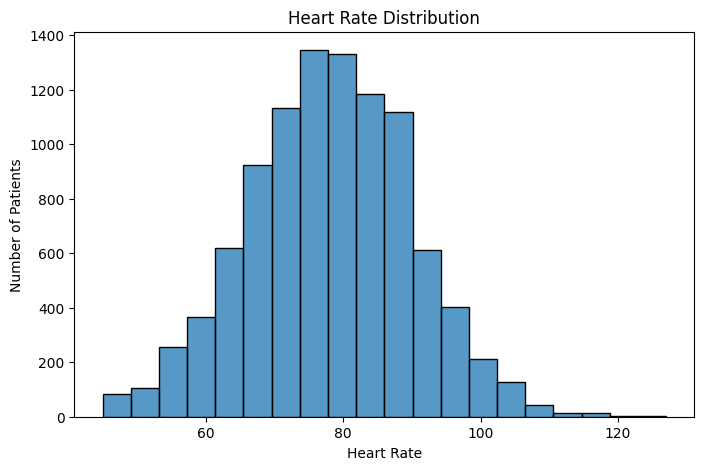

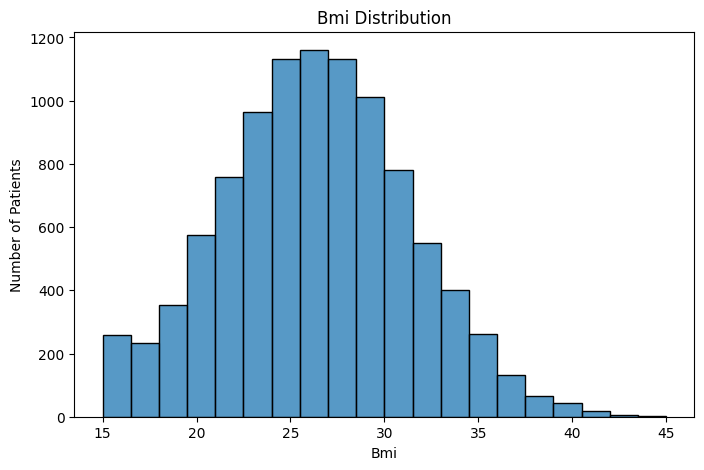

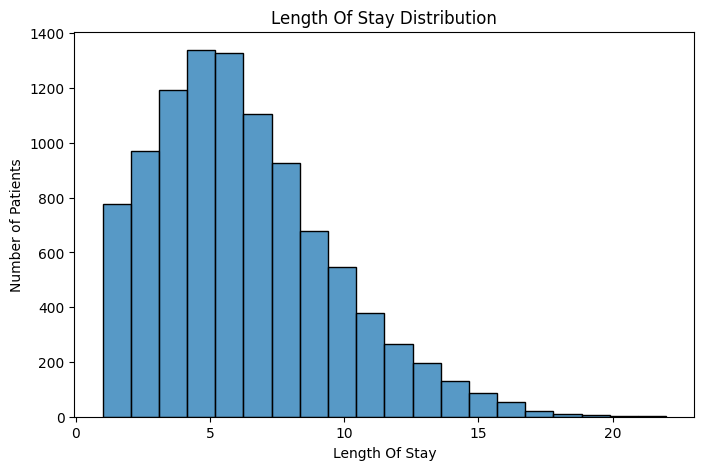

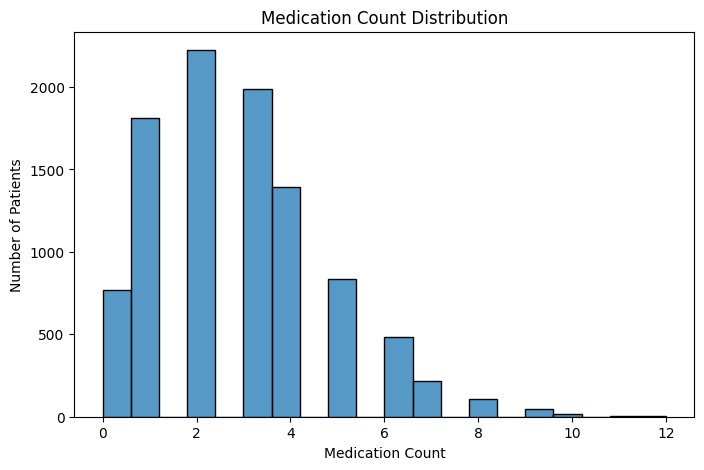

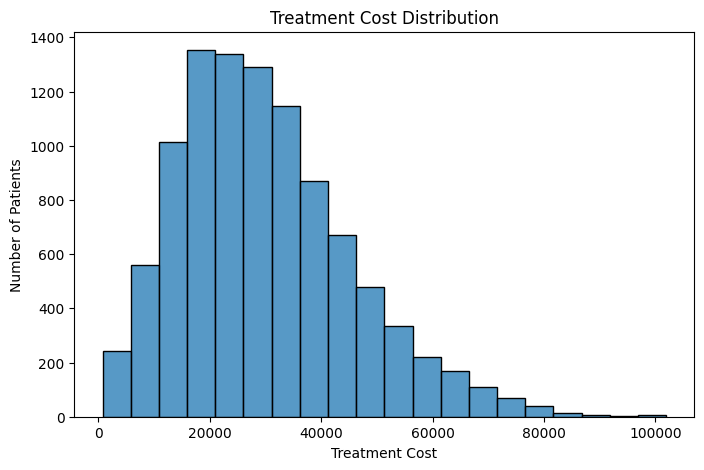

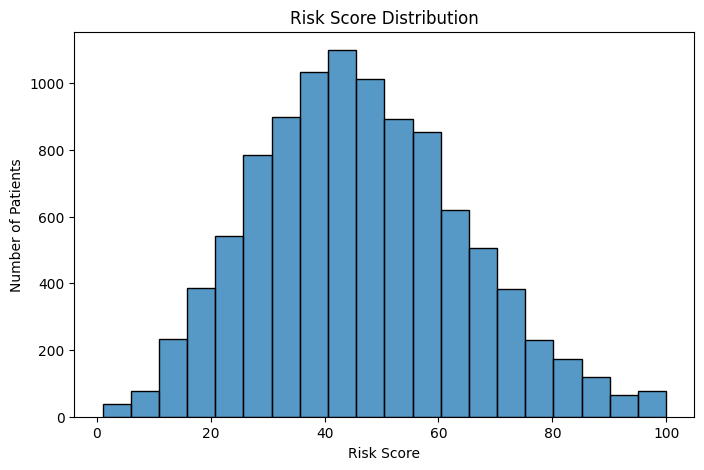

In [18]:
# Numerical Histograms
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, bins=20)
    plt.title(f"{column.replace('_', ' ').title()} Distribution")
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel("Number of Patients")
    plt.show()

## 2. Categorical Variable Percentages

Counts tell us how many patients belong to each category.

Percentages allow us to understand the relative distribution
of each category.

In [19]:
categorical_columns = [
    "gender",
    "smoking_status",
    "diabetes",
    "hypertension",
    "disease",
    "admission_type",
    "readmission"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print(
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


GENDER
gender
Male      49.27
Female    48.86
Other      1.87
Name: proportion, dtype: float64

SMOKING_STATUS
smoking_status
Never      57.62
Former     24.86
Current    17.52
Name: proportion, dtype: float64

DIABETES
diabetes
No     80.39
Yes    19.61
Name: proportion, dtype: float64

HYPERTENSION
hypertension
No     71.42
Yes    28.58
Name: proportion, dtype: float64

DISEASE
disease
Hypertension           18.82
Healthy/Preventive     18.00
Diabetes               16.07
Heart Disease          11.46
Other                  11.30
Respiratory Disease    11.23
Kidney Disease          6.74
Cancer                  6.39
Name: proportion, dtype: float64

ADMISSION_TYPE
admission_type
Elective     43.66
Emergency    31.65
Urgent       24.69
Name: proportion, dtype: float64

READMISSION
readmission
No     79.36
Yes    20.64
Name: proportion, dtype: float64


## 3. Patient Age Groups

Instead of analyzing every individual age separately,
we can group patients into age categories.

This can make demographic patterns easier to understand.

In [20]:
age_bins = [17, 30, 45, 60, 75, 90]

age_labels = [
    "18-30",
    "31-45",
    "46-60",
    "61-75",
    "76-90"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

df["age_group"].value_counts().sort_index()

,count
age_group,
18-30,1888
31-45,2289
46-60,2138
61-75,2217
76-90,1488


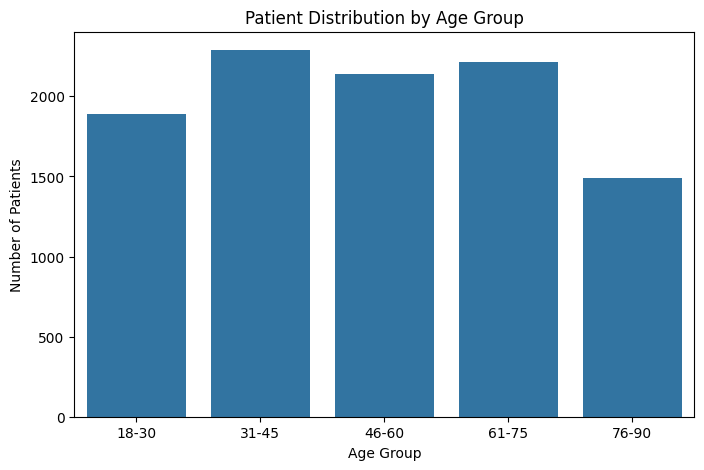

In [21]:
# Visualize Age Group
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age_group"
)

plt.title("Patient Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

## 4. Disease Distribution

Disease distribution is an important part of healthcare analytics.

We want to understand which disease categories are most
common in the dataset.

In [22]:
disease_percentage = (
    df["disease"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

disease_percentage

,proportion
disease,
Hypertension,18.82
Healthy/Preventive,18.00
Diabetes,16.07
Heart Disease,11.46
Other,11.30
Respiratory Disease,11.23
Kidney Disease,6.74
Cancer,6.39


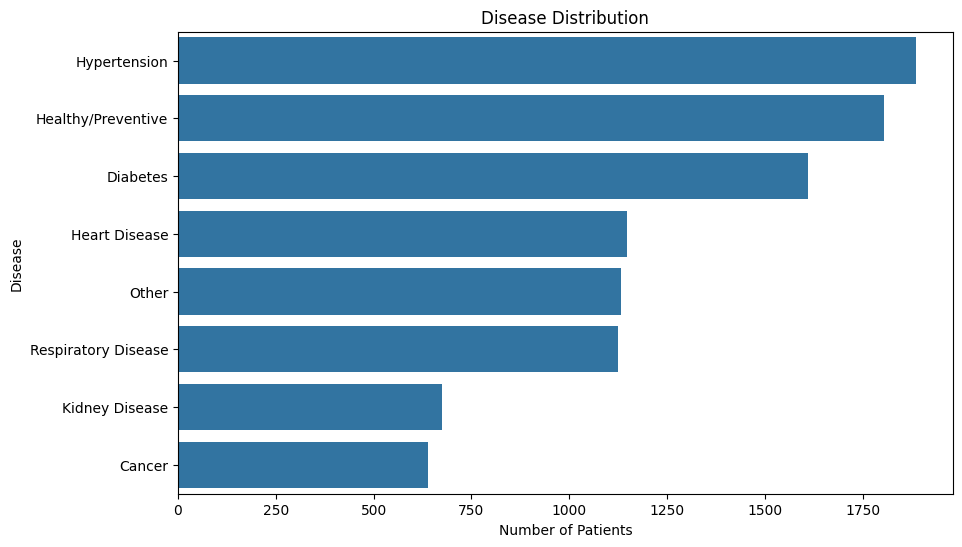

In [24]:
# Visualize Disease
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="disease",
    order=df["disease"].value_counts().index
)

plt.title("Disease Distribution")
plt.xlabel("Number of Patients")
plt.ylabel("Disease")

plt.show()

## 5. Admission Type Distribution

We will analyze how patients entered the healthcare system:

- Elective
- Emergency
- Urgent

In [25]:
admission_percentage = (
    df["admission_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

admission_percentage

,proportion
admission_type,
Elective,43.66
Emergency,31.65
Urgent,24.69


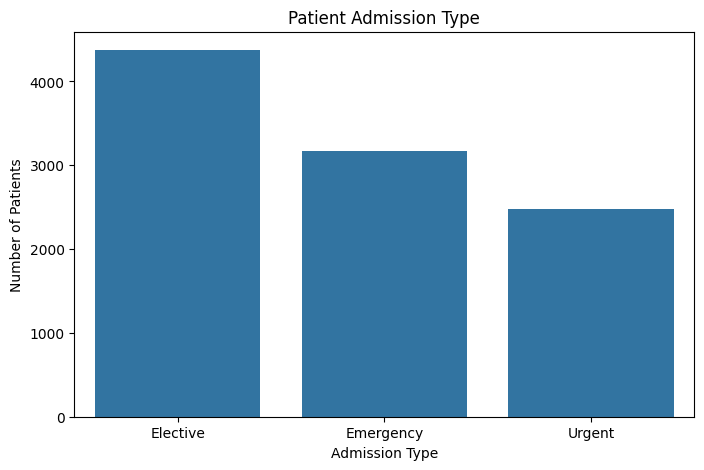

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="admission_type",
    order=df["admission_type"].value_counts().index
)

plt.title("Patient Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Number of Patients")

plt.show()

## 6. Readmission Analysis

Readmission indicates whether a patient was readmitted.

Understanding the proportion of readmitted patients
can help us investigate potential risk factors later.

In [27]:
readmission_percentage = (
    df["readmission"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmission_percentage

,proportion
readmission,
No,79.36
Yes,20.64


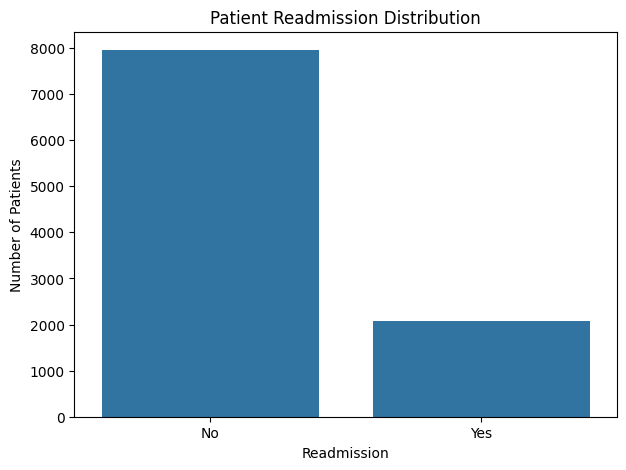

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="readmission"
)

plt.title("Patient Readmission Distribution")
plt.xlabel("Readmission")
plt.ylabel("Number of Patients")

plt.show()

## 7. Disease and Readmission

We will examine the distribution of readmission status
across different disease categories.

This is an initial relationship analysis, not a statistical
test of causation.

In [29]:
disease_readmission = pd.crosstab(
    df["disease"],
    df["readmission"]
)

disease_readmission

readmission,No,Yes
disease,,
Cancer,443,197
Diabetes,1309,301
Healthy/Preventive,1505,299
Heart Disease,843,305
Hypertension,1533,353
Kidney Disease,525,150
Other,904,228
Respiratory Disease,890,235


In [30]:
disease_readmission_percentage = pd.crosstab(
    df["disease"],
    df["readmission"],
    normalize="index"
).mul(100).round(2)

disease_readmission_percentage

readmission,No,Yes
disease,,
Cancer,69.22,30.78
Diabetes,81.30,18.70
Healthy/Preventive,83.43,16.57
Heart Disease,73.43,26.57
Hypertension,81.28,18.72
Kidney Disease,77.78,22.22
Other,79.86,20.14
Respiratory Disease,79.11,20.89


In [32]:
# age group vs readmission
age_readmission = pd.crosstab(
    df["age_group"],
    df["readmission"],
    normalize="index"
).mul(100).round(2)

age_readmission

readmission,No,Yes
age_group,,
18-30,83.26,16.74
31-45,81.35,18.65
46-60,78.53,21.47
61-75,77.81,22.19
76-90,74.87,25.13


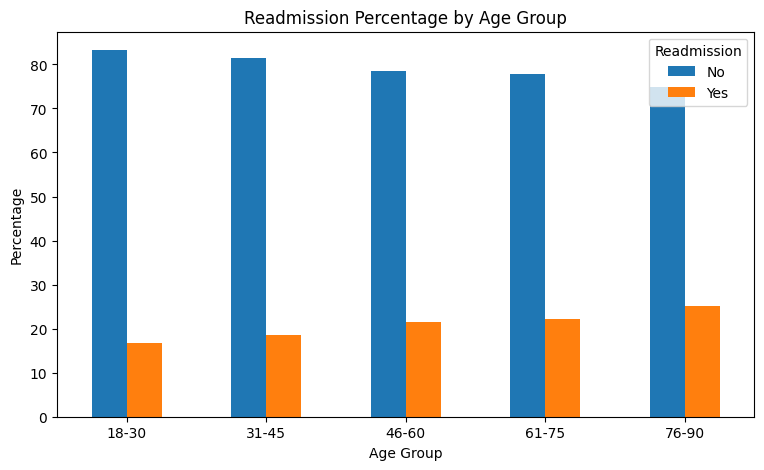

In [33]:
age_readmission.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Readmission Percentage by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Readmission")

plt.show()

## 8. Important Variables for Future Analysis

Based on the initial data understanding, several variables
appear important for future healthcare analysis.

### Demographic Variables

- age
- gender
- smoking_status

### Clinical Variables

- blood_pressure
- heart_rate
- bmi
- diabetes
- hypertension
- disease

### Treatment Variables

- length_of_stay
- medication_count
- treatment_cost

### Outcome / Risk Variables

- readmission
- risk_score

These variables will be investigated in greater detail during
the exploratory data analysis and statistical analysis phases.

In [34]:
df["age_group"].value_counts().sort_index()
df["age_group"].value_counts().idxmax()
df["disease"].value_counts().idxmin()
(df["readmission"] == "Yes").mean() * 100

np.float64(20.638722554890222)

# 📋 Day 2 Observations

## Numerical Variables

- Patient age ranges from 18 to 85 years.
- The average patient age is approximately 51.52 years.
- The average BMI is approximately 26.31.
- The average heart rate is approximately 77.92.
- The average length of stay is approximately 6.50 days.
- The average medication count is approximately 2.82.
- The average treatment cost is approximately ₹29,976.89.
- The average risk score is approximately 46.43.

## Age Groups

- The age groups allow patients to be analyzed by broader
  demographic categories.
- The most represented age group is: **[PUT YOUR OUTPUT HERE]**

## Disease Distribution

- Hypertension is the most common disease category.
- The least common disease category is: **Cancer**

## Admission

- Elective admission is the most common admission type.
- Emergency and urgent admissions make up the remaining
  admission categories.

## Readmission

- Most patients were not readmitted.
- 2,068 records have a readmission status of Yes.
- The readmission rate is approximately **20.64%**.

## Disease and Readmission

- Readmission percentages vary across disease categories.
- Further analysis will be required to understand these
  differences.

## Age and Readmission

- Readmission percentages vary across age groups.
- Further statistical analysis will be required before
  drawing conclusions about relationships.

## Important Variables

The dataset contains demographic, clinical, treatment,
financial, outcome, and risk variables that can be explored
in later stages.

## Overall Day 2 Conclusion

Day 2 provided a deeper understanding of the distributions
and basic relationships within the healthcare dataset.

The dataset appears suitable for further exploratory analysis.
Data cleaning will be performed in the next phase.